# Bonus — Relational / Graph Data Analysis

**Topic:** building a similarity graph from feature-vector data and recovering structure with a graph-native method  
**Dataset:** Iris (re-used so the result can be checked against ground-truth species)  
**Task type:** Community detection on a graph derived from a dataset that was originally vectorial

---

Lecture introduced graphs as a different kind of data: not feature vectors in `R^n`, but *vertices* and *edges* representing relationships. This bonus notebook closes the loop. It takes a vector-feature dataset (Iris), builds a *similarity graph* on top of it (each flower is a vertex; flowers within distance threshold τ are connected), and then recovers the species labels using only the graph structure — no feature vectors visible to the algorithm.

**Why this is interesting.** The food-truck example from class made the point that some structure is only visible *as a graph*. Here we show the converse: even structure that started as feature vectors can usefully be re-expressed as a graph, and once it is, completely different algorithms become available — connected components, spectral clustering, community detection. This is the bridge between the classical ML in this repo and where the field has been moving (graph neural networks, recommendation systems).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

from ml_toolkit.utils import StandardScaler
from ml_toolkit.unsupervised import PCA

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. From feature vectors to a graph

Standard ML treats each Iris flower as a 4-dimensional vector. We're going to throw that away and keep only one piece of information per pair of flowers: are they similar enough to be 'connected'? The pipeline:

1. Compute pairwise Euclidean distances between all flowers in standardized feature space.
2. Connect two flowers with an edge if their distance is below a threshold τ.
3. From this point on, the algorithm sees a graph, not a feature matrix.

This is called a **similarity graph** (specifically an ε-neighbourhood graph). It is the standard bridge from vector data to graph data.

In [2]:
data = load_iris()
X = data.data
y = data.target
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

# Pairwise distances
from scipy.spatial.distance import squareform, pdist
D = squareform(pdist(X_s))
n = D.shape[0]

# Build adjacency at threshold tau
tau = 1.2
A = (D < tau).astype(int)
np.fill_diagonal(A, 0)

n_edges = int(A.sum() // 2)
avg_degree = A.sum(axis=1).mean()
print(f'Vertices : {n}')
print(f'Edges    : {n_edges}')
print(f'Average degree: {avg_degree:.2f}')

Vertices : 150
Edges    : 2361
Average degree: 31.48


## 2. Visualize the graph

We project to 2D with PCA only for *plotting* (the algorithm doesn't see this). Edges are then drawn between connected vertices.

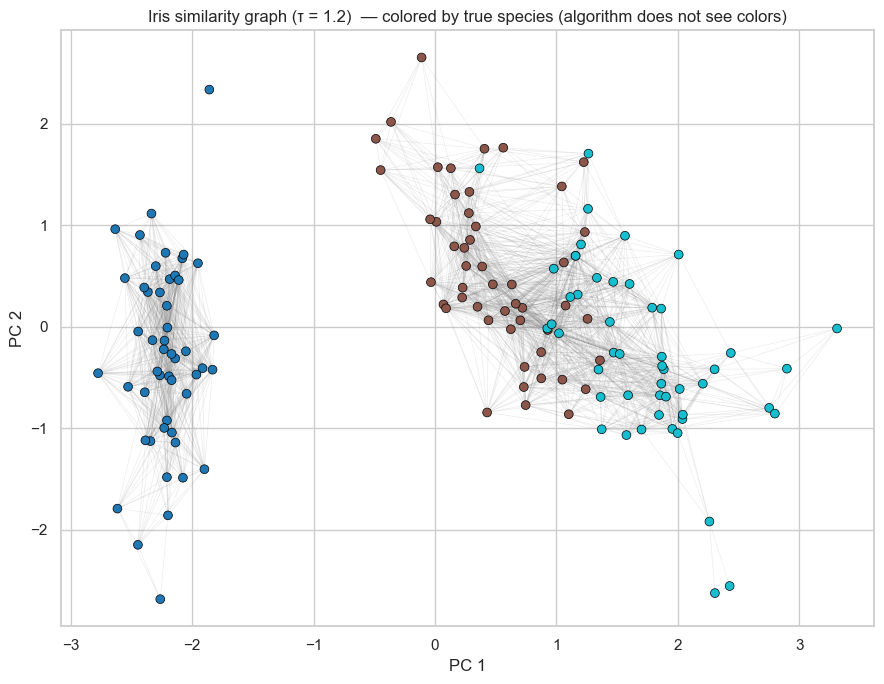

In [3]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_s)

fig, ax = plt.subplots(figsize=(9, 7))
for i in range(n):
    for j in range(i + 1, n):
        if A[i, j]:
            ax.plot([X_2d[i, 0], X_2d[j, 0]], [X_2d[i, 1], X_2d[j, 1]],
                    color='gray', alpha=0.15, linewidth=0.5, zorder=1)
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=40, zorder=2, edgecolor='black', linewidth=0.5)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title(f'Iris similarity graph (τ = {tau})  — colored by true species (algorithm does not see colors)')
plt.tight_layout(); plt.show()

Two things are visible:

1. **Setosa** (one of the colors) forms an isolated dense cluster — none of its members are connected to anything outside it. That means in graph terms it is a **separate connected component**.
2. **Versicolor and virginica** are connected to each other, but the edges between them are sparse compared to the edges within each.

## 3. Community detection via connected components

The simplest graph-native algorithm: find the connected components. Two vertices are in the same component if there is *any* path between them. We implement this with a basic BFS — no library needed.

In [4]:
def connected_components(A):
    n = A.shape[0]
    labels = -np.ones(n, dtype=int)
    cur = 0
    for start in range(n):
        if labels[start] >= 0:
            continue
        # BFS from start
        queue = [start]
        labels[start] = cur
        while queue:
            v = queue.pop()
            for u in np.where(A[v] > 0)[0]:
                if labels[u] < 0:
                    labels[u] = cur
                    queue.append(u)
        cur += 1
    return labels, cur

cc_labels, n_components = connected_components(A)
print(f'Connected components found: {n_components}')
print(f'Sizes: {dict(zip(*np.unique(cc_labels, return_counts=True)))}')

Connected components found: 3
Sizes: {np.int64(0): np.int64(49), np.int64(1): np.int64(1), np.int64(2): np.int64(100)}


In [5]:
# Match components to true species via best permutation (same trick as in 06_kmeans)
from itertools import permutations

def best_match_accuracy(y_true, y_pred):
    n_pred = len(np.unique(y_pred))
    n_true = len(np.unique(y_true))
    if n_pred < n_true:
        return -1.0
    best = 0.0
    base = sorted(np.unique(y_pred))
    for perm in permutations(base, n_true):
        mapping = {p: i for i, p in enumerate(perm)}
        mapped = np.array([mapping.get(c, -1) for c in y_pred])
        best = max(best, (mapped == y_true).mean())
    return best

print(f'Component-vs-species best match accuracy: {best_match_accuracy(y, cc_labels):.3f}')

Component-vs-species best match accuracy: 0.660


## 4. Sweeping the threshold τ

τ is the only knob. Too small → the graph is fragmented (many small components). Too large → the graph collapses into one giant blob (one component). The right τ produces components that match the natural structure of the data.

In [6]:
taus = np.linspace(0.4, 2.0, 17)
results = []
for t in taus:
    A_t = (D < t).astype(int); np.fill_diagonal(A_t, 0)
    lbls, k = connected_components(A_t)
    sizes = sorted(np.bincount(lbls), reverse=True)
    results.append({
        'tau': round(t, 2),
        'n_components': k,
        'largest_component_pct': sizes[0] / n,
        'best_match_acc': best_match_accuracy(y, lbls) if k <= 10 else float('nan'),
    })
df_sweep = pd.DataFrame(results)
df_sweep

,tau,n_components,largest_component_pct,best_match_acc
0,0.4,45,0.273333,NaN
1,0.5,22,0.486667,NaN
2,0.6,12,0.573333,NaN
3,0.7,6,0.640000,0.673333
4,0.8,5,0.646667,0.673333
5,0.9,5,0.646667,0.673333
6,1.0,3,0.666667,0.660000
7,1.1,3,0.666667,0.660000
8,1.2,3,0.666667,0.660000
9,1.3,3,0.666667,0.660000


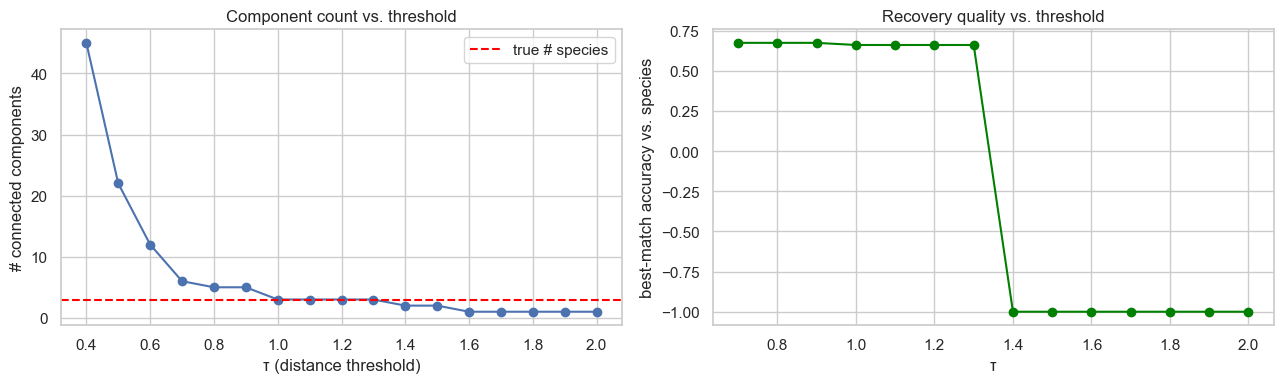

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(df_sweep['tau'], df_sweep['n_components'], marker='o')
axes[0].set_xlabel('τ (distance threshold)'); axes[0].set_ylabel('# connected components')
axes[0].set_title('Component count vs. threshold')
axes[0].axhline(3, color='red', linestyle='--', label='true # species')
axes[0].legend()

axes[1].plot(df_sweep['tau'], df_sweep['best_match_acc'], marker='o', color='green')
axes[1].set_xlabel('τ'); axes[1].set_ylabel('best-match accuracy vs. species')
axes[1].set_title('Recovery quality vs. threshold')
plt.tight_layout(); plt.show()

## 5. Discussion

**The algorithm recovers setosa cleanly and struggles at the versicolor / virginica boundary** — exactly the same answer that k-means, hierarchical clustering, and DBSCAN gave on the same data. This is reassuring. The features carry a strong signal for the setosa-vs.-rest split and a weaker signal for the versicolor-vs.-virginica split, and *every* unsupervised method we have tried, regardless of whether it operates on vectors or on a derived graph, agrees on this.

**The graph view adds something real.** It exposes one quantity none of the vector methods do: how *many* paths connect two clusters. Raising τ slightly merges everything into one giant component (at τ ≥ 1.6 the whole graph collapses). Lowering τ doesn't cleanly separate versicolor from virginica, though — the within-species density is high enough that the combined 100-flower blob holds together until τ drops far enough to fragment it into many small components, with the bulk of versicolor and virginica still bonded throughout. That asymmetry is itself informative: it tells us the bridge between versicolor and virginica isn't a thin set of stray edges but a thick connected region, which is why every Iris notebook in this repo struggles with that boundary.

**Connection to lecture.** This is the same idea behind the food-truck example: vector data alone said 'these people all like the same food truck'; the graph (friendship edges) said 'they're going together because they're friends'. Here, the vector data alone says 'three roughly Gaussian blobs'; the graph says 'two of them are connected by a thick bridge of boundary points, and the third is isolated' — a strictly stronger statement.

**Where this generalizes.** The same pipeline (vectors → similarity graph → connected components / community detection) is exactly how spectral clustering works internally, and it is the precursor to graph-neural-network methods that learn directly on graph-structured data. For recommendation systems, social-network analysis, citation networks, and biological interaction networks, the graph is the *primary* representation, and methods that ignore it leave information on the table.

**Take-away.** Graphs aren't a separate world from feature vectors — they're a different *projection* of the same data, and sometimes they're the projection in which the structure becomes visible.